# Italy and its neighbors: France, Swiss and Austria
## Task A: Optimal Generators Capacities

In [297]:
import matplotlib.pyplot as plt
import pandas as pd

In [298]:
import pypsa

## Prerequisites: handling technology data and costs

We maintain a database (https://github.com/PyPSA/technology-data/tree/v0.11.0, v0.11.0) which collects assumptions and projections for energy system technologies (such as costs, efficiencies, lifetimes, etc.) for given years, which we can load into a `pandas.DataFrame`. This requires some pre-processing to load (e.g. converting units, setting defaults, re-arranging dimensions):

In [299]:
year = 2020

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [300]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"] # already for the CCGT part later

Let's also write a small utility function that calculates the **annuity** to annualise investment costs. The formula is

$$
a(r, n) = \frac{r}{1-(1+r)^{-n}}
$$
where $r$ is the discount rate and $n$ is the lifetime.

In [301]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

In [302]:
annuity(0.07, 20)

0.09439292574325567

Based on this, we can calculate the marginal generation costs (€/MWh):

In [303]:
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

and the annualised investment costs (`capital_cost` in PyPSA terms, €/MW/a):

In [304]:
annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

In [305]:
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

We can now read the capital and marginal cost of onshore wind, solar and OCGT

In [306]:
costs.at["onwind", "capital_cost"] #EUR/MW/a

113584.19278649535

In [307]:
costs.at["solar", "capital_cost"] #EUR/MW/a

75323.80208848667

In [308]:
costs.at["OCGT", "capital_cost"] #EUR/MW/a

49760.036522390714

In [309]:
costs.at["OCGT", "marginal_cost"] #EUR/MWh

66.182

In [310]:
costs.at["CCGT", "marginal_cost"] #EUR/MWh

48.527628571428565

In [311]:
costs.at["CCGT", "capital_cost"] #EUR/MWh

110915.22632898652

## Retrieving time series data

wind data from [https://zenodo.org/record/3253876#.XSiVOEdS8l0](https://zenodo.org/record/3253876#.XSiVOEdS8l0) and solar PV data from [https://zenodo.org/record/2613651#.X0kbhDVS-uV](https://zenodo.org/record/3253876#.XSiVOEdS8l0) is used.

In [312]:
data_solar = pd.read_csv('data/pv_optimal.csv',sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv',sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv',sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

data_solar.head()

,utc_time,AUT,BEL,BGR,BIH,CHE,CYP,CZE,DEU,DNK,...,MLT,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
utc_time,,,,,,,,,,,,,,,,,,,,,
1979-01-01 00:00:00+00:00,1979-01-01T00:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 01:00:00+00:00,1979-01-01T01:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 02:00:00+00:00,1979-01-01T02:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 03:00:00+00:00,1979-01-01T03:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 04:00:00+00:00,1979-01-01T04:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We will use timeseries for Italy

In [313]:
country = 'ITA'

### Joint capacity and dispatch optimization

For building the model, we start again by initialising an empty network, adding the snapshots, and the electricity bus.

In [314]:
n = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

n.set_snapshots(hours_in_2015.values)

n.add("Bus", "ITA")

n.snapshots

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2015-12-31 14:00:00', '2015-12-31 15:00:00',
               '2015-12-31 16:00:00', '2015-12-31 17:00:00',
               '2015-12-31 18:00:00', '2015-12-31 19:00:00',
               '2015-12-31 20:00:00', '2015-12-31 21:00:00',
               '2015-12-31 22:00:00', '2015-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

In [315]:
carriers = [
    "onwind",
    "solar",
    "OCGT",
    "CCGT",
]

n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred","yellow-green"],
)

Next, we add the demand time series to the model.

In [316]:
# add load to the bus
n.add("Load",
      "demand",
      bus="ITA",
      p_set=data_el[country].values)

Let's have a check whether the data was read-in correctly.

<Axes: title={'center': 'Electricity demand in Italy in 2015'}, xlabel='snapshot', ylabel='MW'>

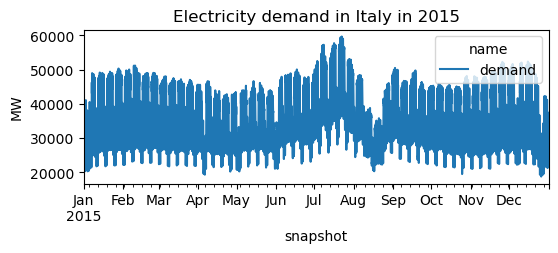

In [317]:
n.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW", title="Electricity demand in Italy in 2015")

We now add the generators and set up their capacities to be extendable so that they can be optimized together with the dispatch time series. For the wind and solar generator, we need to indicate the capacity factor or maximum power per unit 'p_max_pu'

In [318]:
n.add(
    "Generator",
    "OCGT",
    bus="ITA",
    carrier="OCGT",
    capital_cost=costs.at["OCGT", "capital_cost"],
    marginal_cost=costs.at["OCGT", "marginal_cost"],
    efficiency=costs.at["OCGT", "efficiency"],
    p_nom_extendable=True,
)

CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "onwind",
        bus="ITA",
        carrier="onwind",
        p_max_pu=CF_wind.values,
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "solar",
        bus="ITA",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )

So let's make sure the capacity factors are read-in correctly.

<Axes: xlabel='snapshot', ylabel='CF'>

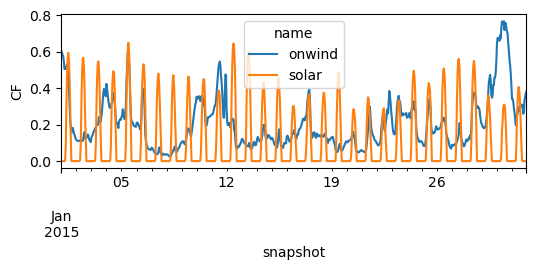

In [319]:
n.generators_t.p_max_pu.loc["2015-01"].plot(figsize=(6, 2), ylabel="CF")

### Model Run

We can already solved the model using the open-solver "highs" or the commercial solver "gurobi" with the academic license

In [320]:
n.optimize()

Index(['ITA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 313.87it/s]
INFO:linopy.io: Writing time: 0.11s


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-a9bq_gom has 61323 rows; 26283 cols; 100919 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [1e-02, 1e+05]
  Bound   [0e+00, 0e+00]
  RHS     [2e+04, 6e+04]
Presolving model
26632 rows, 17875 cols, 57820 nonzeros  0s
Dependent equations search running on 4556 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
26632 rows, 17875 cols, 57820 nonzeros  0s
Presolve reductions: rows 26632(-34691); columns 17875(-8408); nonzeros 57820(-43099) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26283 primals, 61323 duals
Objective: 2.27e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


      18196     2.2670381414e+10 Pr: 0(0) 1s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-a9bq_gom
Model status        : Optimal
Simplex   iterations: 18196
Objective value     :  2.2670381414e+10
P-D objective error :  1.5144110178e-15
HiGHS run time      :          0.62


('ok', 'optimal')

Now, we can look at the results and evaluate the total system cost (in billion Euros per year)

In [321]:
n.objective / 1e9

22.670381413833148

The optimised capacities in GW:

In [322]:
n.generators.p_nom_opt.div(1e3)  # MW -> GW

name
OCGT      52.558000
onwind    -0.000000
solar     66.122671
Name: p_nom_opt, dtype: float64

The total energy generation by technology in TWh:

In [323]:
n.generators_t.p.sum().div(1e6)  # MWh -> TWh

name
OCGT      227.759279
onwind      0.000000
solar      86.585790
dtype: float64

We can plot the dispatch of every generator thoughout January

<Axes: xlabel='snapshot', ylabel='dispatch'>

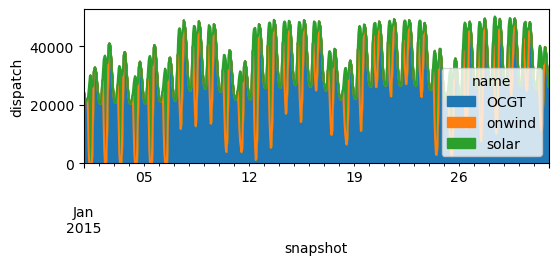

In [324]:
n.generators_t.p.loc["2015-01"].plot.area(figsize=(6, 2), ylabel="dispatch")

<Axes: xlabel='snapshot', ylabel='demand'>

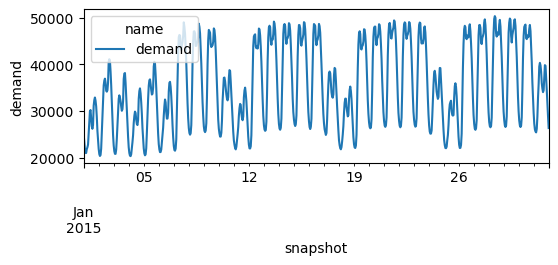

In [325]:
n.loads_t.p.loc["2015-01"].plot(figsize=(6, 2), ylabel="demand")

**b) Calculate the revenues collected by every technology throughout the year and show that their sum is equal to their costs.**

To calculate the revenues collected by every technology, we multiply the energy generated in every hour by the electricity price in that hour and sum for the entire year.

In [326]:
n.generators_t.p.multiply(n.buses_t.marginal_price.to_numpy()).sum().div(1e6) # EUR -> MEUR

name
OCGT      17688.852635
onwind        0.000000
solar      4981.528779
dtype: float64

This corresponds to the total cost for every technology, which we can also read using the statistics module:

In [327]:
(n.statistics.capex() + n.statistics.opex()).div(1e6)

component  carrier
Generator  OCGT       17688.852635
           solar       4981.528779
dtype: float64

**Now we are adding the possibility of installing battery storage. The annualised capital cost of the battery comprises 12,894 EUR/MWh/a for the energy capacity and 24,678 EUR/MW/a for the inverter. The inverter efficiency is 0.96 and the battery is assumed to have a fixed energy-to-power ratio of 2 hours. Assume also an existing combined-cycle gas turbine (CCGT) unit with an electricity generation capacity of 6 GW and efficiency of 0.58. The annualised capital cost and marginal generation costs for the CCGT are respectively 104,788 EUR/MW/a and 46.8 EUR/MWh.**

Let's build the model from scratch to include the battery storage and the CCGT generator.

In [328]:
n = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

n.set_snapshots(hours_in_2015.values)

n.add("Bus",
            "ITA")

n.snapshots

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2015-12-31 14:00:00', '2015-12-31 15:00:00',
               '2015-12-31 16:00:00', '2015-12-31 17:00:00',
               '2015-12-31 18:00:00', '2015-12-31 19:00:00',
               '2015-12-31 20:00:00', '2015-12-31 21:00:00',
               '2015-12-31 22:00:00', '2015-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

We add all the technologies we are going to include as carriers. Defining carriers is not mandatory but will ease plotting and assigning emissions of CO2 in future steps. 

In [329]:
carriers = [
    "onwind",
    "solar",
    "OCGT",
    "CCGT",
    "battery storage",
]

n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred","yellow-green", "brown"],

)

Next, we add the demand time series to the model.

In [330]:
# add load to the bus
n.add("Load",
      "demand",
      bus="ITA",
      p_set=data_el[country].values)

Let's have a check whether the data was read-in correctly.

<Axes: xlabel='snapshot', ylabel='MW'>

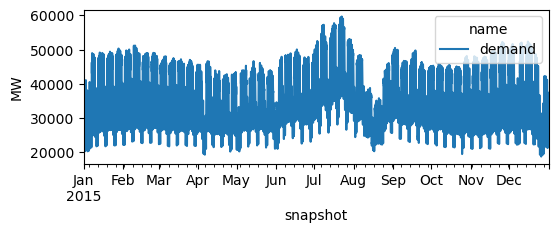

In [331]:
n.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW")

We add now the generators and set up their capacities to be extendable so that they can be optimized together with the dispatch time series. For the wind and solar generator, we need to indicate the capacity factor or maximum power per unit 'p_max_pu'

In [332]:
n.add(
    "Generator",
    "OCGT",
    bus="ITA",
    carrier="OCGT",
    capital_cost=costs.at["OCGT", "capital_cost"],
    marginal_cost=costs.at["OCGT", "marginal_cost"],
    efficiency=costs.at["OCGT", "efficiency"],
    p_nom_extendable=True,
)

CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "onwind",
        bus="ITA",
        carrier="onwind",
        p_max_pu=CF_wind.values,
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "solar",
        bus="ITA",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )

So let's make sure the capacity factors are read-in correctly.

<Axes: xlabel='snapshot', ylabel='CF'>

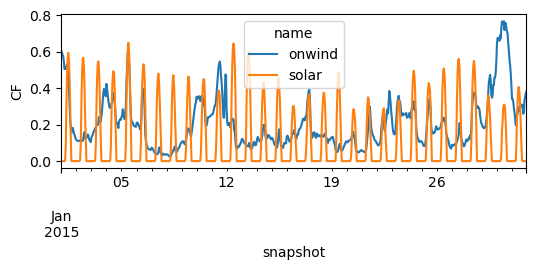

In [333]:
n.generators_t.p_max_pu.loc["2015-01"].plot(figsize=(6, 2), ylabel="CF")

We add the battery storage, assuming a fixed energy-to-power ratio of 2 hours, i.e. if fully charged, the battery can discharge at full capacity for 2 hours. 

For the capital cost, we have to factor in both the capacity and energy cost of the storage. 

We include the charging and discharging efficiencies we enforce a cyclic state-of-charge condition, i.e. the state of charge at the beginning of the optimisation period must equal the final state of charge.

We add the Combined Cycle Gas Turbine (CCGT). In this case, its capacity is not extendable but fixed to 1 GW. 

In [334]:
n.add(
    "Generator",
    "CCGT",
    bus="ITA",
    carrier="CCGT",
    capital_cost=costs.at["CCGT", "capital_cost"],
    marginal_cost=costs.at["CCGT", "marginal_cost"],
    efficiency=costs.at["CCGT", "efficiency"],
    p_nom=6000, #6 Gw
)

### Model Run

We can already solved the model using the open-solver "highs" or the commercial solver "gurobi" with the academic license

In [335]:
n.optimize() # solver_name="highs"

Index(['ITA'], dtype='object', name='name')


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 320.25it/s]
INFO:linopy.io: Writing time: 0.12s


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-kvnw_sx5 has 78843 rows; 35043 cols; 127199 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [1e-02, 1e+05]
  Bound   [0e+00, 0e+00]
  RHS     [6e+03, 6e+04]
Presolving model
30836 rows, 30839 cols, 74988 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
30836 rows, 30839 cols, 74988 nonzeros  0s
Presolve reductions: rows 30836(-48007); columns 30839(-4204); nonzeros 74988(-52211) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(3.14345e+08) 0s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35043 primals, 78843 duals
Objective: 2.15e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


      22568     2.1495305448e+10 Pr: 0(0) 1s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-kvnw_sx5
Model status        : Optimal
Simplex   iterations: 22568
Objective value     :  2.1495305448e+10
P-D objective error :  2.6921672575e-13
HiGHS run time      :          0.64


('ok', 'optimal')

Now, we can look at the results and evaluate the total system cost (in billion Euros per year)

In [336]:
n.objective / 1e9

21.4953054480545

The optimised capacities in GW:

In [337]:
n.generators.p_nom_opt.div(1e3)  # MW -> GW

name
OCGT      46.55800
onwind    -0.00000
solar     62.26094
CCGT       6.00000
Name: p_nom_opt, dtype: float64

The optimised battery capacity can be calcualted as 

In [338]:
n.storage_units.p_nom_opt.div(1e3)  # MW -> GW

Series([], Name: p_nom_opt, dtype: float64)

The total energy generation by technology in TWh:

In [339]:
n.generators_t.p.sum().div(1e6)  # MWh -> TWh

name
OCGT      182.231579
onwind      0.000000
solar      82.089895
CCGT       50.023595
dtype: float64

We can plot the dispatch of every generator thoughout January

<Axes: xlabel='snapshot', ylabel='dispatch'>

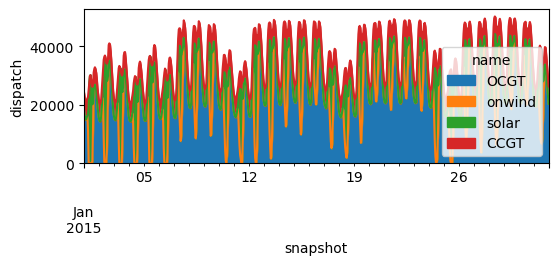

In [340]:
n.generators_t.p.loc["2015-01"].plot.area(figsize=(6, 2), ylabel="dispatch")

and the demand time series

<Axes: xlabel='snapshot', ylabel='demand'>

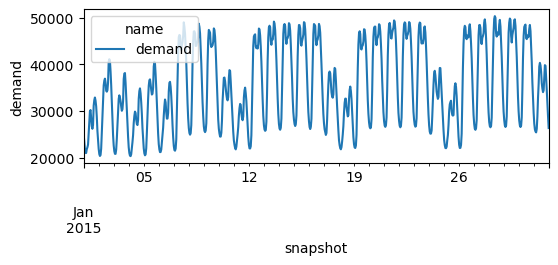

In [341]:
n.loads_t.p.loc["2015-01"].plot(figsize=(6, 2), ylabel="demand")

**d) How does the CCGT power plant recover its cost?**

To calculate the revenues collected by every technology, for every generator, we multiply the energy generated in very hour by the electricity price in that hour and sum for the entire year.

In [342]:
n.generators_t.p.multiply(n.buses_t.marginal_price.to_numpy()).sum().div(1e6) # EUR -> MEUR

name
OCGT      14377.178147
onwind        0.000000
solar      4690.600878
CCGT       3587.670025
dtype: float64

This corresponds to the total cost for every technology, which we can also read using the statistics module:

In [343]:
(n.statistics.capex() + n.statistics.opex()).div(1e6)

component  carrier
Generator  CCGT        3093.017781
           OCGT       14377.178147
           solar       4690.600878
dtype: float64

The CCGT does not recover its full cost. This is to be expected because its capacity was not optimized but set exogenously 

The battery capacity is also co-optimized with the dispatch, so it exactly recovers its cost by buying electricity when the price is low and selling when it is high. The revenues from market can be calculated by multiplying the battery charging and discharging by the electricity price time series

In [344]:
n.storage_units_t.p.multiply(n.buses_t.marginal_price.to_numpy()).sum().div(1e6) # EUR -> MEUR

Series([], dtype: float64)

The market revenues exactly correspons with the total battery costs

In [345]:
n.storage_units.p_nom_opt*(costs.at["battery inverter", "capital_cost"]+ 2 * costs.at["battery storage", "capital_cost"])/(1e6)# EUR -> MEUR

Series([], Name: p_nom_opt, dtype: float64)

## Task C: adding a storage system

In [346]:
# n.add(
#     "StorageUnit",
#     "battery storage",
#     bus="ITA",
#     carrier="battery storage",
#     max_hours=2,
#     capital_cost=costs.at["battery inverter", "capital_cost"]
#     + 2 * costs.at["battery storage", "capital_cost"],
#     efficiency_store=costs.at["battery inverter", "efficiency"],
#     efficiency_dispatch=costs.at["battery inverter", "efficiency"],
#     p_nom_extendable=True,
#     cyclic_state_of_charge=True,
# )

In [347]:
# plot the charging and discharging of the battery
# n.storage_units_t.p.loc["2015-01"].plot(figsize=(6, 2), ylabel="battery")

### C.1 — Model with Battery Storage

Same system as Part A (Wind, Solar, OCGT — all extendable, same costs) and added an extendable **battery storage** unit. The battery has a 2-hour energy-to-power ratio, consistent with short-duration lithium-ion systems suited for intraday solar shifting.


In [348]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def annuity(y, r):
    if r > 0:
        return r / (1.0 - 1.0 / (1.0 + r) ** y)
    else:
        return 1 / y

def strip_tz(s):
    """Return a copy of Series/DataFrame with timezone-naive index."""
    if hasattr(s.index, 'tz') and s.index.tz is not None:
        s = s.copy()
        s.index = s.index.tz_convert(None)
    return s

year    = 2010
country = "ITA"

demand     = pd.read_csv('data/electricity_demand.csv',     sep=';', index_col=0)
data_wind  = pd.read_csv('data/onshore_wind_1979-2017.csv', sep=';', index_col=0)
data_solar = pd.read_csv('data/pv_optimal.csv',             sep=';', index_col=0)

demand.index     = pd.to_datetime(demand.index)
data_wind.index  = pd.to_datetime(data_wind.index, utc=True)
data_solar.index = pd.to_datetime(data_solar.index)

capital_cost_wind  = annuity(30, 0.07) * 910_000  * (1 + 0.033)
capital_cost_solar = annuity(25, 0.07) * 425_000  * (1 + 0.030)
capital_cost_OCGT  = annuity(25, 0.07) * 560_000  * (1 + 0.033)
fuel_cost          = 21.6
efficiency_OCGT    = 0.39
marginal_cost_OCGT = fuel_cost / efficiency_OCGT

# Battery costs — separated into two components per PyPSA convention:
#   Inverter  : annuity(20, 0.07) * 310,000 = 24,678 €/MW/a   (power electronics)
#   Cell      : annuity(20, 0.07) * 150,000 = 12,894 €/MWh/a  (energy storage)
# These are added to separate components (Link + StorageUnit) in the network.
capital_cost_inverter = annuity(20, 0.07) * 310_000   # €/MW/a
capital_cost_cells    = annuity(20, 0.07) * 150_000   # €/MWh/a
eta_battery           = 0.96   # one-way efficiency (inverter)

print(f"Inverter capital cost : {capital_cost_inverter:,.0f} €/MW/a")
print(f"Cell capital cost     : {capital_cost_cells:,.0f} €/MWh/a")
print(f"Combined (per MW, 2h) : {capital_cost_inverter + 2*capital_cost_cells:,.0f} €/MW/a")
print(f"One-way efficiency    : {eta_battery:.2f}  |  round-trip: {eta_battery**2:.3f}")

Inverter capital cost : 29,262 €/MW/a
Cell capital cost     : 14,159 €/MWh/a
Combined (per MW, 2h) : 57,580 €/MW/a
One-way efficiency    : 0.96  |  round-trip: 0.922


### C.2 — Solve

In [349]:
nc = pypsa.Network()
snapshots = pd.date_range(f'{year}-01-01 00:00Z', f'{year}-12-31 23:00Z', freq='h')
nc.set_snapshots(snapshots.values)
nc.add("Bus", "ITA")
nc.add("Bus", "ITA_bat_dc", carrier="Battery")

nc.add("Carrier", "Gas",     co2_emissions=0.19)
nc.add("Carrier", "Wind")
nc.add("Carrier", "Solar")
nc.add("Carrier", "Battery")

nc.add('Load', "Demand", bus='ITA', p_set=demand[country].values)

cf_wind = data_wind[country][[h.strftime("%Y-%m-%dT%H:%M:%SZ") for h in nc.snapshots]]
nc.add("Generator", "Wind",
       bus="ITA", carrier="Wind", p_nom_extendable=True,
       capital_cost=capital_cost_wind, marginal_cost=0,
       p_max_pu=cf_wind.values)

cf_solar = data_solar[country][[h.strftime("%Y-%m-%dT%H:%M:%SZ") for h in nc.snapshots]]
nc.add("Generator", "Solar",
       bus="ITA", carrier="Solar", p_nom_extendable=True,
       capital_cost=capital_cost_solar, marginal_cost=0,
       p_max_pu=cf_solar.values)

nc.add("Generator", "OCGT",
       bus="ITA", carrier="Gas", p_nom_extendable=True,
       capital_cost=capital_cost_OCGT,
       marginal_cost=marginal_cost_OCGT)

nc.add("Link", "Battery_inverter",
       bus0="ITA",
       bus1="ITA_bat_dc",
       carrier="Battery",
       capital_cost=capital_cost_inverter,
       efficiency=eta_battery,
       p_min_pu=-1,
       p_nom_extendable=True)

nc.add("StorageUnit", "Battery",
       bus="ITA_bat_dc",
       carrier="Battery",
       max_hours=2,
       capital_cost=capital_cost_cells,
       efficiency_store=1.0,
       efficiency_dispatch=1.0,
       p_nom_extendable=True,
       cyclic_state_of_charge=True)

def extra_functionality(n, snapshots):
    inv_var = n.model.variables["Link-p_nom"]
    bat_var = n.model.variables["StorageUnit-p_nom"]
    inv_dim = list(inv_var.dims)[0]
    bat_dim = list(bat_var.dims)[0]
    inv_nom = inv_var.sel({inv_dim: "Battery_inverter"})
    bat_nom = bat_var.sel({bat_dim: "Battery"})
    n.model.add_constraints(bat_nom == inv_nom, name="battery_coupling")

nc.optimize(solver_name='highs', extra_functionality=extra_functionality)
print(f"Objective: {nc.objective/1e6:.2f} M€/a")

# Check 2h ratio
inv = nc.links.at["Battery_inverter", "p_nom_opt"]
bat = nc.storage_units.at["Battery", "p_nom_opt"]
print(f"Inverter : {inv/1e3:.2f} GW")
print(f"Cells    : {bat/1e3:.2f} GW  →  {bat*2/1e3:.2f} GWh")
print(f"Ratio    : {bat*2/inv:.2f}h  (should be 2.00h)")

Index(['ITA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 537.20it/s]
INFO:linopy.io: Writing time: 0.23s


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-hndts6gs has 148926 rows; 61325 cols; 284876 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 2e+00]
  Cost    [6e+01, 8e+04]
  Bound   [0e+00, 0e+00]
  RHS     [2e+04, 6e+04]
Presolving model
92149 rows, 57113 cols, 223887 nonzeros  0s
Dependent equations search running on 17520 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
83389 rows, 48353 cols, 223887 nonzeros  0s
Presolve reductions: rows 83389(-65537); columns 48353(-12972); nonzeros 223887(-60989) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 11180(3.07359e+08) 0s
      52326     1.6689829752e+10 Pr: 18267(5.2712e+08); Du: 0(2.4e-07) 5s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 148926 duals
Objective: 1.67e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, battery_coupling were not assigned to the network.


      54328     1.6702789481e+10 Pr: 0(0); Du: 0(6.82059e-12) 6s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-hndts6gs
Model status        : Optimal
Simplex   iterations: 54328
Objective value     :  1.6702789481e+10
P-D objective error :  2.1125782460e-15
HiGHS run time      :          5.61
Objective: 16702.79 M€/a
Inverter : 12.95 GW
Cells    : 12.95 GW  →  25.91 GWh
Ratio    : 2.00h  (should be 2.00h)


### C.3 — Optimal capacity and generation mix

In [350]:
COLORS = {'Wind': 'steelblue', 'Solar': 'gold', 'OCGT': 'indianred', 'Battery': 'slategray'}

# Inverter p_nom_opt gives the power capacity (MW)
# StorageUnit p_nom_opt gives energy capacity relative to max_hours
bat_p_nom = nc.links.at["Battery_inverter", "p_nom_opt"]      # MW (power)
bat_e_nom = nc.storage_units.at["Battery", "p_nom_opt"] * 2   # MWh (energy)

print("=== Optimal capacities ===")
print(nc.generators.p_nom_opt.div(1e3).rename("GW").to_string())
print(f"Battery inverter : {bat_p_nom/1e3:.2f} GW")
print(f"Battery cells    : {bat_e_nom/1e3:.2f} GWh")

print("\n=== Annual generation ===")
gen_energy = nc.generators_t.p.sum().div(1e6)   # TWh

# Battery discharge: when Link flow is negative (DC->AC), power flows back to ITA
bat_link_p0 = strip_tz(nc.links_t.p0["Battery_inverter"])  # positive=charging, negative=discharging
bat_discharge_mwh = bat_link_p0.clip(upper=0).abs().sum() / 1e6   # TWh


print(gen_energy.rename("TWh").to_string())
print(f"Battery discharge: {bat_discharge_mwh:.2f} TWh")
print(f"Total demand:      {nc.loads_t.p_set.sum().values[0]/1e6:.2f} TWh")

=== Optimal capacities ===
name
Wind     59.695981
Solar    67.341242
OCGT     42.573548
Battery inverter : 12.95 GW
Battery cells    : 25.91 GWh

=== Annual generation ===
name
Wind     108.803305
Solar     79.599972
OCGT     125.941792
Battery discharge: 32.76 TWh
Total demand:      314.35 TWh


### C.4 — Annual electricity mix

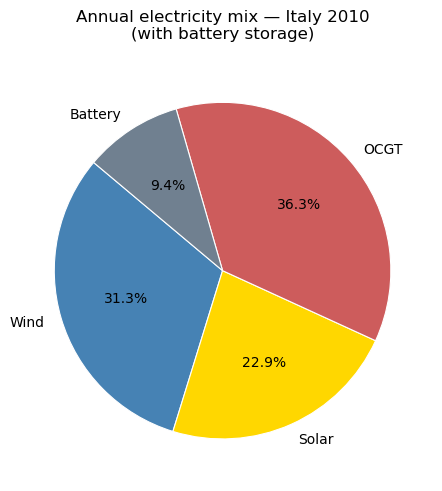

In [351]:
mix = {g: nc.generators_t.p[g].sum() for g in ['Wind', 'Solar', 'OCGT']}
bat_link_p0_full = strip_tz(nc.links_t.p0["Battery_inverter"])
mix['Battery'] = bat_link_p0_full.clip(upper=0).abs().sum()   # discharge only
mix = {k: v for k, v in mix.items() if v > 1e3}

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(mix.values(),
       labels=mix.keys(),
       colors=[COLORS[k] for k in mix],
       autopct='%1.1f%%',
       wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'},
       startangle=140)
ax.set_title(f'Annual electricity mix — Italy {year}\n(with battery storage)', y=1.03)
fig.tight_layout()
plt.savefig('pics/taskC_mix.png', dpi=150, bbox_inches='tight')
plt.show()

### C.5 — Time series for summer and winter

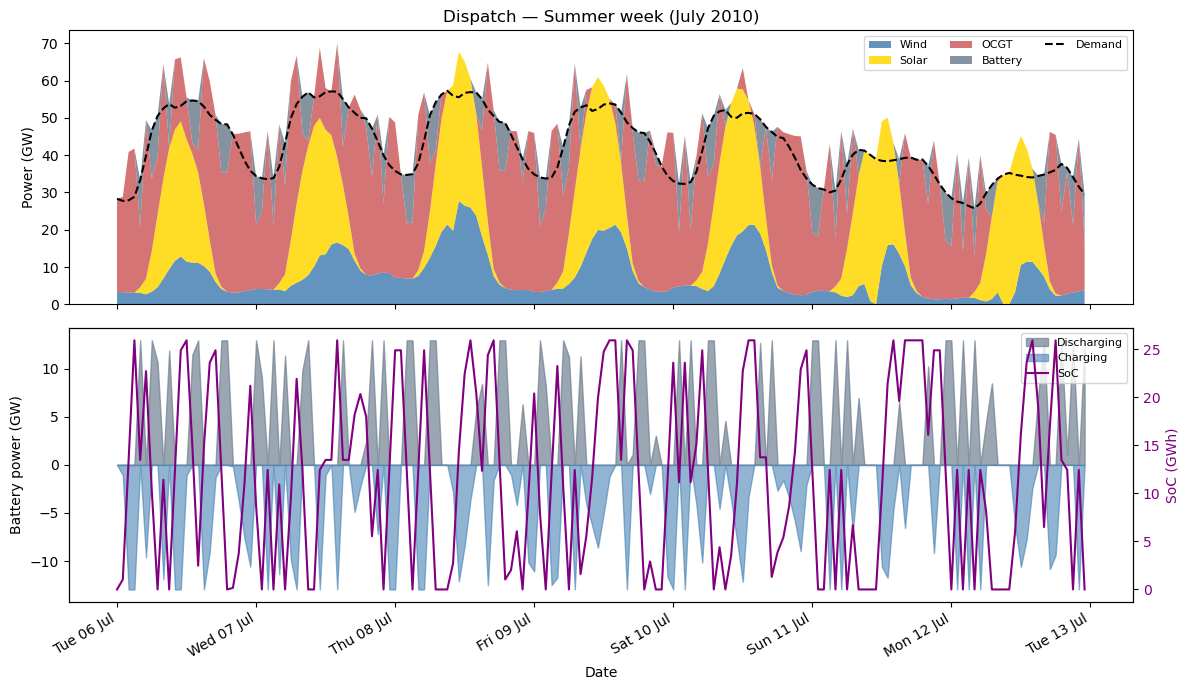

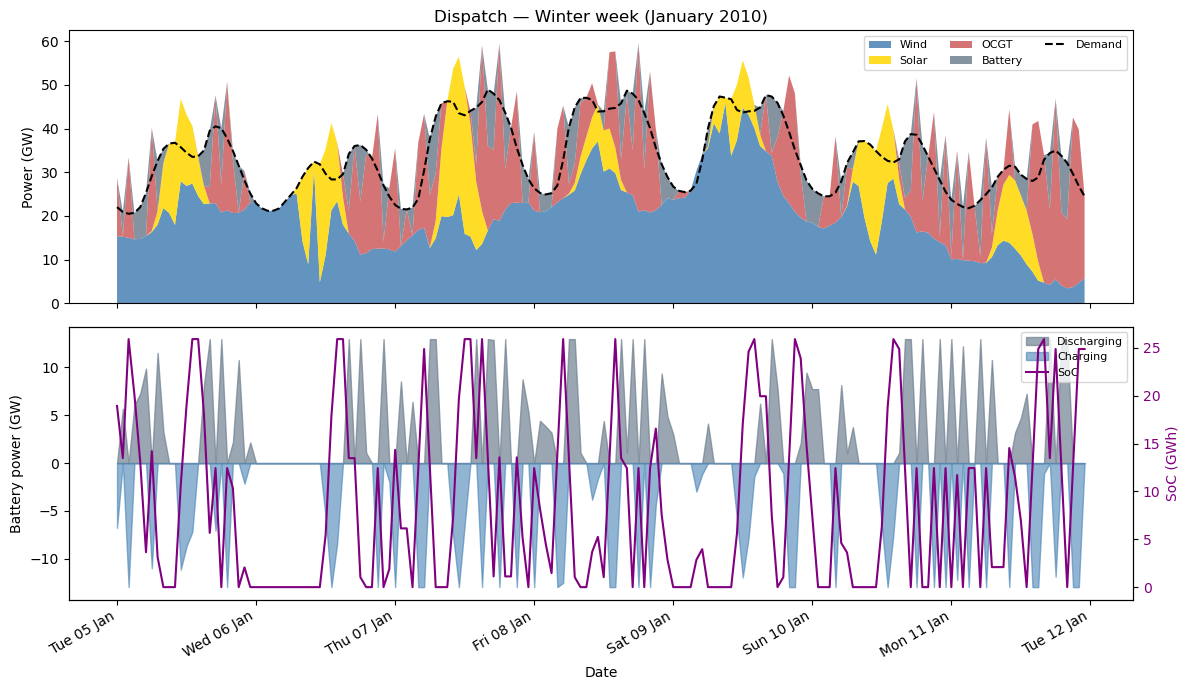

In [352]:
def plot_week(network, start_str, title, fname):
    """Stacked dispatch + battery power + SoC for one week."""
    gen_p  = strip_tz(network.generators_t.p)
    # Battery power seen from the AC bus: Link p0
    # positive p0 = charging (power leaves AC bus)
    # negative p0 = discharging (power enters AC bus)
    bat_p0 = strip_tz(network.links_t.p0["Battery_inverter"])
    soc    = strip_tz(network.storage_units_t.state_of_charge["Battery"])
    dem    = strip_tz(network.loads_t.p["Demand"])

    t0 = pd.Timestamp(start_str)
    t1 = t0 + pd.Timedelta(hours=167)
    gen_p  = gen_p.loc[t0:t1]
    bat_p0 = bat_p0.loc[t0:t1]
    soc    = soc.loc[t0:t1]
    dem    = dem.loc[t0:t1]

    bat_discharge = bat_p0.clip(upper=0).abs()   # MW delivered to AC bus
    bat_charge    = bat_p0.clip(lower=0)          # MW taken from AC bus

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    # Top: stacked generation + battery discharge
    plot_df = gen_p.copy()
    plot_df['Battery'] = bat_discharge
    cols   = ['Wind', 'Solar', 'OCGT', 'Battery']
    colors = [COLORS[c] for c in cols]
    axes[0].stackplot(plot_df.index, [plot_df[c] / 1e3 for c in cols],
                      labels=cols, colors=colors, alpha=0.85)
    axes[0].plot(dem.index, dem.values / 1e3, 'k--', lw=1.5, label='Demand')
    axes[0].set_ylabel('Power (GW)')
    axes[0].set_title(title)
    axes[0].legend(loc='upper right', ncol=3, fontsize=8)

    # Bottom: battery charge/discharge + SoC
    axes[1].fill_between(bat_discharge.index,  0,  bat_discharge / 1e3,
                         color=COLORS['Battery'], alpha=0.7, label='Discharging')
    axes[1].fill_between(bat_charge.index,     0, -bat_charge / 1e3,
                         color='steelblue', alpha=0.6, label='Charging')
    ax2b = axes[1].twinx()
    ax2b.plot(soc.index, soc.values / 1e3, color='purple', lw=1.5, label='SoC')
    ax2b.set_ylabel('SoC (GWh)', color='purple')
    ax2b.tick_params(axis='y', labelcolor='purple')
    axes[1].set_ylabel('Battery power (GW)')
    axes[1].set_xlabel('Date')
    l1, lab1 = axes[1].get_legend_handles_labels()
    l2, lab2 = ax2b.get_legend_handles_labels()
    axes[1].legend(l1 + l2, lab1 + lab2, loc='upper right', fontsize=8)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b'))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

plot_week(nc, f'{year}-07-06', f'Dispatch — Summer week (July {year})', 'pics/taskC_summer.png')
plot_week(nc, f'{year}-01-05', f'Dispatch — Winter week (January {year})', 'pics/taskC_winter.png')

### C.6 — SOC of full year

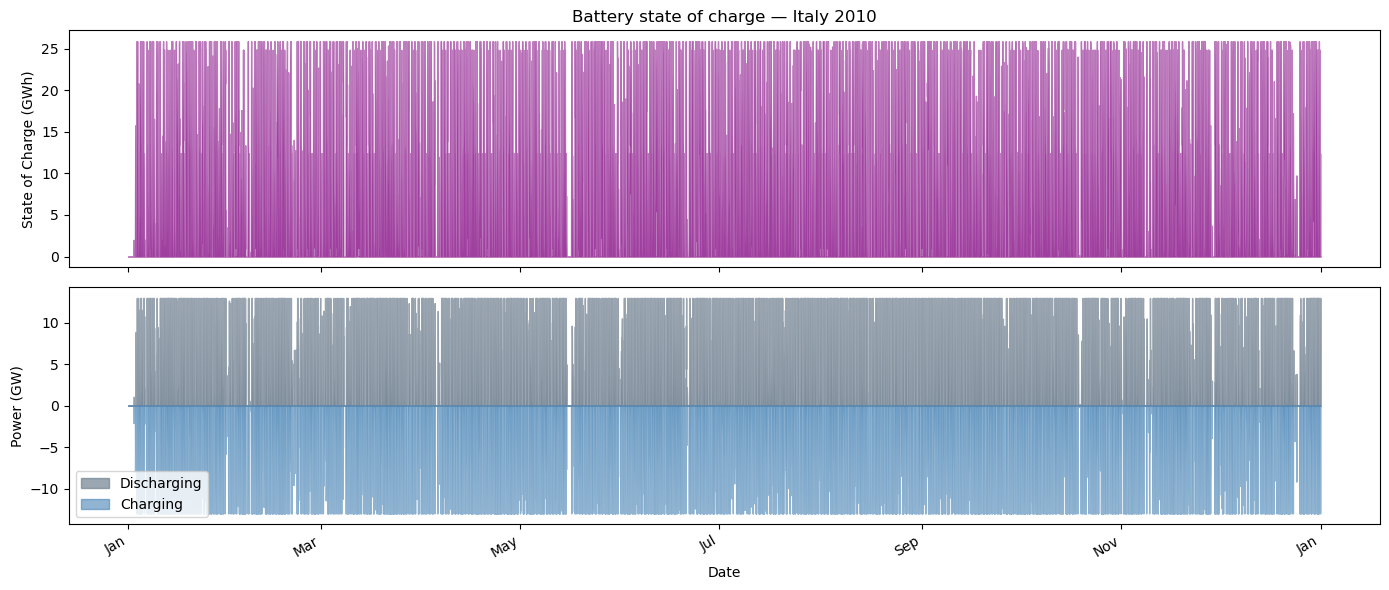

Non-zero SoC hours: 6106 / 8760


In [353]:
soc_full   = strip_tz(nc.storage_units_t.state_of_charge["Battery"])
bat_p_full = strip_tz(nc.links_t.p0["Battery_inverter"])
# convention: negative = discharging (power flows to AC), positive = charging
bat_discharge_full = bat_p_full.clip(upper=0).abs()
bat_charge_full    = bat_p_full.clip(lower=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].fill_between(soc_full.index, soc_full.values / 1e3, color='purple', alpha=0.5)
axes[0].set_ylabel('State of Charge (GWh)')
axes[0].set_title(f'Battery state of charge — Italy {year}')

axes[1].fill_between(bat_discharge_full.index, 0,  bat_discharge_full.values / 1e3,
                     color=COLORS['Battery'], alpha=0.7, label='Discharging')
axes[1].fill_between(bat_charge_full.index,    0, -bat_charge_full.values / 1e3,
                     color='steelblue', alpha=0.6, label='Charging')
axes[1].set_ylabel('Power (GW)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
fig.autofmt_xdate()
fig.tight_layout()
plt.savefig('pics/taskC_soc_full_year.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Non-zero SoC hours: {(soc_full > 0).sum()} / {len(soc_full)}")

### C.7 — Duration curve

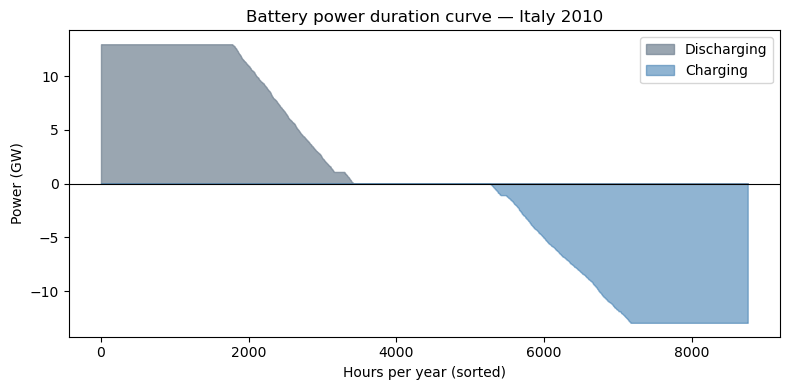

Hours discharging : 3425
Hours charging    : 3493
Max discharge     : 12.954 GW
Max charge        : 12.954 GW


In [354]:
fig, ax = plt.subplots(figsize=(8, 4))

hours = np.arange(1, len(bat_discharge_full) + 1)
ax.fill_between(hours,
                0, np.sort(bat_discharge_full.values)[::-1] / 1e3,
                color=COLORS['Battery'], alpha=0.7, label='Discharging')
ax.fill_between(hours,
                np.sort(-bat_charge_full.values)[::-1] / 1e3, 0,
                color='steelblue', alpha=0.6, label='Charging')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Hours per year (sorted)')
ax.set_ylabel('Power (GW)')
ax.set_title(f'Battery power duration curve — Italy {year}')
ax.legend()
fig.tight_layout()
plt.savefig('pics/taskC_duration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Hours discharging : {(bat_discharge_full > 1).sum()}")
print(f"Hours charging    : {(bat_charge_full > 1).sum()}")
print(f"Max discharge     : {bat_discharge_full.max()/1e3:.3f} GW")
print(f"Max charge        : {bat_charge_full.max()/1e3:.3f} GW")

### C.8 — Comparison

In [355]:
n_no_bat = pypsa.Network()
snapshots = pd.date_range(f'{year}-01-01 00:00Z', f'{year}-12-31 23:00Z', freq='h')
n_no_bat.set_snapshots(snapshots.values)
n_no_bat.add("Bus", "ITA")
n_no_bat.add("Carrier", "Gas", co2_emissions=0.19)
n_no_bat.add("Carrier", "Wind")
n_no_bat.add("Carrier", "Solar")
n_no_bat.add('Load', "Demand", bus='ITA', p_set=demand[country].values)

cf_wind_nb  = data_wind[country][[h.strftime("%Y-%m-%dT%H:%M:%SZ") for h in n_no_bat.snapshots]]
cf_solar_nb = data_solar[country][[h.strftime("%Y-%m-%dT%H:%M:%SZ") for h in n_no_bat.snapshots]]

n_no_bat.add("Generator", "Wind",  bus="ITA", carrier="Wind",
             p_nom_extendable=True, capital_cost=capital_cost_wind,
             marginal_cost=0, p_max_pu=cf_wind_nb.values)
n_no_bat.add("Generator", "Solar", bus="ITA", carrier="Solar",
             p_nom_extendable=True, capital_cost=capital_cost_solar,
             marginal_cost=0, p_max_pu=cf_solar_nb.values)
n_no_bat.add("Generator", "OCGT",  bus="ITA", carrier="Gas",
             p_nom_extendable=True, capital_cost=capital_cost_OCGT,
             marginal_cost=marginal_cost_OCGT)

n_no_bat.optimize(solver_name='highs')

print(f"Cost WITHOUT battery: {n_no_bat.objective/1e6:.2f} M€/a")
print(f"Cost WITH battery:    {nc.objective/1e6:.2f} M€/a")
print(f"Saving from storage:  {(n_no_bat.objective - nc.objective)/1e6:.2f} M€/a")

Index(['ITA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 371.67it/s]
INFO:linopy.io: Writing time: 0.09s


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-cz15tf6w has 61323 rows; 26283 cols; 100912 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+00]
  Cost    [6e+01, 8e+04]
  Bound   [0e+00, 0e+00]
  RHS     [2e+04, 6e+04]
Presolving model
26618 rows, 17861 cols, 57785 nonzeros  0s
Dependent equations search running on 4549 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
26618 rows, 17861 cols, 57785 nonzeros  0s
Presolve reductions: rows 26618(-34705); columns 17861(-8422); nonzeros 57785(-43127) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26283 primals, 61323 duals
Objective: 1.69e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


      17253     1.6862312519e+10 Pr: 0(0); Du: 0(1.59831e-11) 1s
      17253     1.6862312519e+10 Pr: 0(0); Du: 0(1.59831e-11) 1s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-cz15tf6w
Model status        : Optimal
Simplex   iterations: 17253
Objective value     :  1.6862312519e+10
P-D objective error :  2.1491491147e-15
HiGHS run time      :          0.78
Cost WITHOUT battery: 16862.31 M€/a
Cost WITH battery:    16702.79 M€/a
Saving from storage:  159.52 M€/a


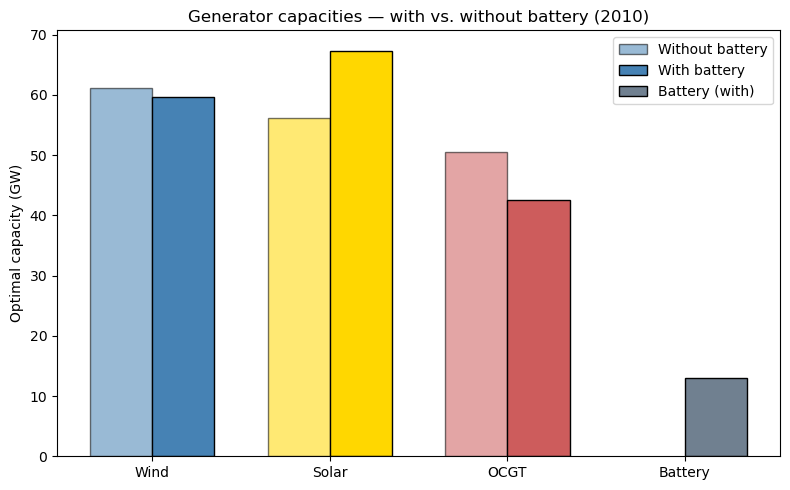

In [356]:
gens        = ['Wind', 'Solar', 'OCGT']
cap_with    = [nc.generators.loc[g, 'p_nom_opt']       / 1e3 for g in gens]
cap_without = [n_no_bat.generators.loc[g, 'p_nom_opt'] / 1e3 for g in gens]
bat_cap_gw  = nc.links.at["Battery_inverter", "p_nom_opt"] / 1e3

x     = np.arange(len(gens) + 1)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x[:3] - width/2, cap_without, width,
       label='Without battery', color=[COLORS[g] for g in gens], alpha=0.55, edgecolor='k')
ax.bar(x[:3] + width/2, cap_with,    width,
       label='With battery',    color=[COLORS[g] for g in gens], alpha=1.0,  edgecolor='k')
ax.bar(x[3]  + width/2, bat_cap_gw,  width,
       label='Battery (with)',  color=COLORS['Battery'], edgecolor='k')

ax.set_xticks(x)
ax.set_xticklabels(gens + ['Battery'])
ax.set_ylabel('Optimal capacity (GW)')
ax.set_title(f'Generator capacities — with vs. without battery ({year})')
ax.legend()
fig.tight_layout()
plt.savefig('pics/taskC_capacity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### C.9 — Battery costs and revenue

In [357]:
bat_p0_s = strip_tz(nc.links_t.p0["Battery_inverter"])
price    = strip_tz(nc.buses_t.marginal_price)
if isinstance(price, pd.DataFrame):
    price = price["ITA"] if "ITA" in price.columns else price.squeeze()

bat_p0_s, price = bat_p0_s.align(price, join="inner")

# Discharging: negative p0 → power enters AC bus → revenue
# Charging:    positive p0 → power leaves AC bus → cost
discharge = bat_p0_s.clip(upper=0).abs()
charge    = bat_p0_s.clip(lower=0)

rev_discharge = (discharge * price).sum() / 1e6   # M€
cost_charging = (charge    * price).sum() / 1e6   # M€
net_revenue   = rev_discharge - cost_charging

# Total annualised cost = inverter cost + cell cost
inverter_cost = nc.links.at["Battery_inverter", "p_nom_opt"] * capital_cost_inverter / 1e6
cell_cost     = nc.storage_units.at["Battery", "p_nom_opt"]  * capital_cost_cells    / 1e6
total_bat_cost = inverter_cost + cell_cost

print(f"Revenue from discharging : {rev_discharge:.2f} M€/a")
print(f"Cost of charging         : {cost_charging:.2f} M€/a")
print(f"Net revenue              : {net_revenue:.2f} M€/a")
print(f"Inverter capital cost    : {inverter_cost:.2f} M€/a")
print(f"Cell capital cost        : {cell_cost:.2f} M€/a")
print(f"Total battery cost       : {total_bat_cost:.2f} M€/a")
print(f"Ratio (should be ≈ 1.0)  : {net_revenue/total_bat_cost:.4f}")

Revenue from discharging : 2073.30 M€/a
Cost of charging         : 1510.84 M€/a
Net revenue              : 562.45 M€/a
Inverter capital cost    : 379.04 M€/a
Cell capital cost        : 183.41 M€/a
Total battery cost       : 562.45 M€/a
Ratio (should be ≈ 1.0)  : 1.0000


### C.10 — Intraday and seasonal storage analysis

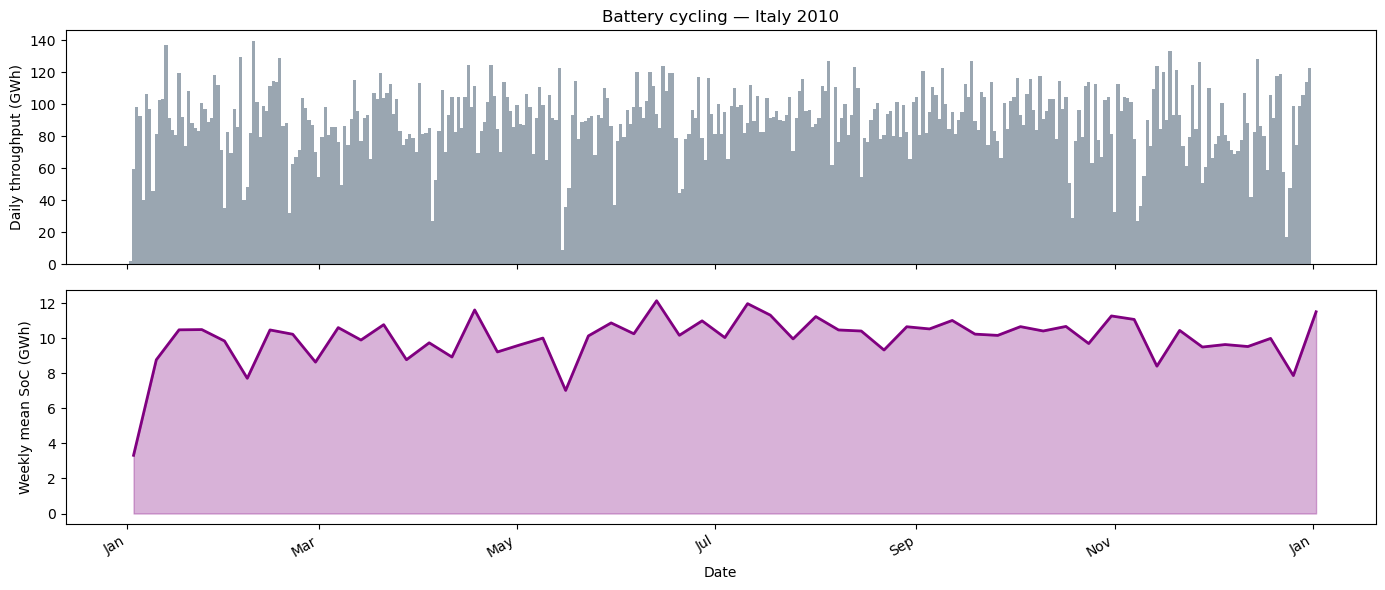

Battery power capacity    : 12.95 GW
Battery energy capacity   : 25.91 GWh
Total annual discharge    : 32.76 TWh
Equivalent full cycles/yr : 1264.6
Avg daily throughput      : 89.760 GWh/day


In [358]:
bat_discharge_ts = bat_discharge_full   # already tz-naive from C.6

intraday_throughput = bat_discharge_ts.resample("D").sum() / 1e3   # GWh/day
soc_weekly          = soc_full.resample("W").mean() / 1e3          # GWh

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].bar(intraday_throughput.index, intraday_throughput.values,
            color=COLORS['Battery'], alpha=0.7, width=1)
axes[0].set_ylabel('Daily throughput (GWh)')
axes[0].set_title(f'Battery cycling — Italy {year}')

axes[1].plot(soc_weekly.index, soc_weekly.values, color='purple', lw=2)
axes[1].fill_between(soc_weekly.index, 0, soc_weekly.values, color='purple', alpha=0.3)
axes[1].set_ylabel('Weekly mean SoC (GWh)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
fig.autofmt_xdate()
fig.tight_layout()
plt.savefig('pics/taskC_intraday_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

max_energy      = nc.storage_units.at["Battery", "p_nom_opt"] * 2   # MWh
total_discharge = bat_discharge_ts.sum()                              # MWh
n_cycles        = total_discharge / max_energy if max_energy > 0 else 0

print(f"Battery power capacity    : {nc.links.at['Battery_inverter', 'p_nom_opt']/1e3:.2f} GW")
print(f"Battery energy capacity   : {max_energy/1e3:.2f} GWh")
print(f"Total annual discharge    : {total_discharge/1e6:.2f} TWh")
print(f"Equivalent full cycles/yr : {n_cycles:.1f}")
print(f"Avg daily throughput      : {total_discharge/365/1e3:.3f} GWh/day")